import library

In [16]:
import pandas as pd
import numpy as np
import re
import string
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [17]:
DATA_PATH = "data/comment.csv"
df = pd.read_csv(DATA_PATH)
print(df.columns)
print(df.shape)


Index(['comment', 'sentiment'], dtype='object')
(4141, 2)


In [18]:
df.head()

,comment,sentiment
0,"overall, faculty bilkul supportive nahi hai.",Negative
1,"mere according, practical sessions useful nahi...",Negative
2,"experience ke according, class ka environment ...",Negative
3,mujhe lagta hai ki practical sessions bahut us...,Positive
4,mujhe lagta hai ki teacher ka explanation conf...,Negative


In [19]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Missing values:
comment      0
sentiment    0
dtype: int64

Duplicate rows:
0

Sentiment distribution:
sentiment
Positive    1386
Negative    1384
Neutral     1371
Name: count, dtype: int64


In [20]:
print(df["sentiment"].unique())
print(df["sentiment"].value_counts())

['Negative' 'Positive' 'Neutral']
sentiment
Positive    1386
Negative    1384
Neutral     1371
Name: count, dtype: int64


In [21]:
df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()

print(df["sentiment"].value_counts())

sentiment
positive    1386
negative    1384
neutral     1371
Name: count, dtype: int64


In [22]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [23]:
df["clean_comment"] = df["comment"].apply(clean_text)

df[["comment", "clean_comment"]].head(10)

,comment,clean_comment
0,"overall, faculty bilkul supportive nahi hai.",overall faculty bilkul supportive nahi hai
1,"mere according, practical sessions useful nahi...",mere according practical sessions useful nahi ...
2,"experience ke according, class ka environment ...",experience ke according class ka environment a...
3,mujhe lagta hai ki practical sessions bahut us...,mujhe lagta hai ki practical sessions bahut us...
4,mujhe lagta hai ki teacher ka explanation conf...,mujhe lagta hai ki teacher ka explanation conf...
5,"Overall, The instructor gives confusing explan...",overall the instructor gives confusing explana...
6,"mere according, practical sessions bahut usefu...",mere according practical sessions bahut useful...
7,"experience ke according, lectures interesting ...",experience ke according lectures interesting a...
8,"For me, The practical sessions are very useful...",for me the practical sessions are very useful ...
9,"generally, teacher lecture me examples dete ha...",generally teacher lecture me examples dete hai...


In [24]:
X = df["clean_comment"]
y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4141,)
y shape: (4141,)


In [27]:
y.head()

0    negative
1    negative
2    negative
3    positive
4    negative
Name: sentiment, dtype: object

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3312
Testing samples: 829


In [29]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            max_features=10000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

In [30]:
print("Training model...")

model.fit(X_train, y_train)

print("✅ Model training completed!")

Training model...
✅ Model training completed!


In [32]:
y_pred = model.predict(X_test)

print("Predictions completed!")



Predictions completed!


In [33]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.88%


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       277
     neutral       1.00      1.00      1.00       274
    positive       1.00      1.00      1.00       278

    accuracy                           1.00       829
   macro avg       1.00      1.00      1.00       829
weighted avg       1.00      1.00      1.00       829



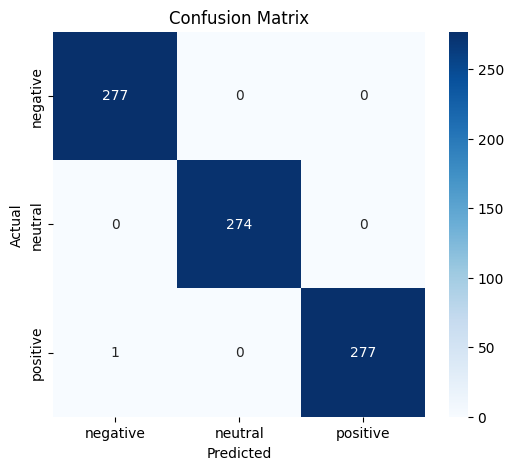

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
test_comments = [
    "The teacher explains everything very clearly",
    "The teacher does not teach properly",
    "I really enjoyed this class",
    "The class was very boring and difficult"
]

predictions = model.predict(test_comments)
probabilities = model.predict_proba(test_comments)

for comment, prediction, probability in zip(
    test_comments,
    predictions,
    probabilities
):
    confidence = max(probability) * 100

    print("--------------------------------")
    print("Comment:", comment)
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")

--------------------------------
Comment: The teacher explains everything very clearly
Prediction: positive
Confidence: 93.62%
--------------------------------
Comment: The teacher does not teach properly
Prediction: negative
Confidence: 98.96%
--------------------------------
Comment: I really enjoyed this class
Prediction: positive
Confidence: 36.94%
--------------------------------
Comment: The class was very boring and difficult
Prediction: negative
Confidence: 62.58%


In [41]:
test_comments = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "Excellent class and very helpful teacher",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "Worst teaching experience"
]

for comment in test_comments:
    prediction = model.predict([comment])[0]
    probability = model.predict_proba([comment])[0]

    confidence = max(probability) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 96.39%

Comment: Teacher explains topics clearly
Sentiment: positive
Confidence: 74.78%

Comment: I am very satisfied with the teaching
Sentiment: positive
Confidence: 84.70%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 98.76%

Comment: I cannot understand anything in this class
Sentiment: negative
Confidence: 43.99%

Comment: Very poor teaching
Sentiment: positive
Confidence: 86.81%

Comment: Excellent class and very helpful teacher
Sentiment: positive
Confidence: 96.13%

Comment: The lectures are boring
Sentiment: negative
Confidence: 85.56%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 88.84%

Comment: Worst teaching experience
Sentiment: positive
Confidence: 54.50%


In [42]:
# Negative words ka dataset me distribution check karo

words = ["poor", "worst", "boring", "bad", "not", "cannot", "terrible", "waste"]

for word in words:
    temp = df[df["clean_comment"].str.contains(
        rf"\b{word}\b",
        case=False,
        regex=True,
        na=False
    )]

    print(f"\n===== {word.upper()} =====")
    print(temp["sentiment"].value_counts())

    if len(temp) > 0:
        print(temp[["comment", "sentiment"]].head(10).to_string(index=False))


===== POOR =====
sentiment
negative    1
Name: count, dtype: int64
                                                                  comment sentiment
From my experience, Class ka learning experience poor hai. In this class.  negative

===== WORST =====
Series([], Name: count, dtype: int64)

===== BORING =====
sentiment
negative    137
Name: count, dtype: int64
                                                                       comment sentiment
        Mujhe lagta hai ki lectures boring aur difficult lagte hain. abhi tak.  negative
   mere according, lectures boring aur difficult lagte hain. students ke liye.  negative
          mere according, lectures boring aur difficult lagte hain. course me.  negative
             meri taraf se, lectures boring aur difficult lagte hain. overall.  negative
         mujhe lagta hai ki lectures boring aur difficult lagte hain. overall.  negative
        From my side, The lessons are boring and difficult to follow. Overall.  negative
mujhe lagta 

In [43]:
import pandas as pd

# Existing dataset
df = pd.read_csv("data/comment.csv")

# Additional negative examples
extra_negative = [
    "Very poor teaching",
    "Poor teaching experience",
    "The teaching quality is poor",
    "The teacher is very poor at explaining",
    "Worst teaching experience",
    "This is the worst teaching I have experienced",
    "Worst teacher ever",
    "The teaching is bad",
    "Very bad teaching",
    "The teacher does a bad job explaining",
    "The class was terrible",
    "Terrible teaching experience",
    "The teacher is not helpful",
    "The teacher does not explain properly",
    "I cannot understand the teacher",
    "I cannot understand anything in this class",
    "The teacher fails to explain concepts",
    "The class is extremely boring",
    "The lectures are boring",
    "The teaching method is boring",
    "The class is difficult to follow",
    "I am disappointed with the teaching",
    "I am not satisfied with the teaching",
    "The teacher is not supportive",
    "The lessons are not useful",
    "The practical sessions are not useful",
    "The teacher does not answer questions",
    "The teacher does not clear doubts",
    "The explanations are not clear",
    "The teaching is not effective",
    "The teacher does not teach well",
    "I am unhappy with the teaching",
    "The class is a waste of time",
    "The teaching experience was disappointing",
    "The teacher needs to improve",
    "The course is not useful",
    "The lectures are not interesting",
    "The teacher speaks too fast",
    "The teacher does not pay attention to students",
    "The concepts are not explained clearly",
    "The teacher is unable to explain properly",
    "I learned very little from this class",
    "The teaching quality needs improvement",
    "The class was a bad experience",
    "The lecture was very boring",
    "I did not enjoy the class",
    "The teacher does not help students",
    "The learning experience was poor"
]

extra_df = pd.DataFrame({
    "comment": extra_negative,
    "sentiment": "negative"
})

# Combine
df = pd.concat([df, extra_df], ignore_index=True)

# Remove duplicates
df = df.drop_duplicates(
    subset=["comment", "sentiment"]
).reset_index(drop=True)

# Save updated dataset
df.to_csv("data/final_comments.csv", index=False)

print("✅ Dataset updated")
print("Total rows:", len(df))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

✅ Dataset updated
Total rows: 4189

Sentiment distribution:
sentiment
Positive    1386
Negative    1384
Neutral     1371
negative      48
Name: count, dtype: int64


In [44]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_comment"] = df["comment"].apply(clean_text)

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = df["clean_comment"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            C=2.0,
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

model.fit(X_train, y_train)

print("✅ Model trained successfully")

✅ Model trained successfully


In [46]:
test_comments = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "Excellent class and very helpful teacher",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "Worst teaching experience"
]

for comment in test_comments:
    prediction = model.predict([comment])[0]
    probability = model.predict_proba([comment])[0]

    confidence = max(probability) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: Positive
Confidence: 73.00%

Comment: Teacher explains topics clearly
Sentiment: Positive
Confidence: 64.64%

Comment: I am very satisfied with the teaching
Sentiment: negative
Confidence: 95.22%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 93.91%

Comment: I cannot understand anything in this class
Sentiment: negative
Confidence: 93.73%

Comment: Very poor teaching
Sentiment: negative
Confidence: 96.24%

Comment: Excellent class and very helpful teacher
Sentiment: Positive
Confidence: 83.72%

Comment: The lectures are boring
Sentiment: Negative
Confidence: 59.35%

Comment: The teacher is supportive and helpful
Sentiment: negative
Confidence: 85.79%

Comment: Worst teaching experience
Sentiment: negative
Confidence: 97.69%


In [47]:
positive_words = [
    "satisfied",
    "supportive",
    "helpful",
    "excellent",
    "good",
    "great",
    "very well",
    "clearly",
    "enjoy",
    "happy"
]

for word in positive_words:
    temp = df[
        df["clean_comment"].str.contains(
            rf"\b{word}\b",
            case=False,
            regex=True,
            na=False
        )
    ]

    print(f"\n===== {word.upper()} =====")
    print("Total:", len(temp))

    if len(temp) > 0:
        print(temp["sentiment"].value_counts())
        print(temp[["comment", "sentiment"]].head(5).to_string(index=False))


===== SATISFIED =====
Total: 2
sentiment
Positive    1
negative    1
Name: count, dtype: int64
                                                          comment sentiment
In my opinion, I am satisfied with the teaching quality. Overall.  Positive
                             I am not satisfied with the teaching  negative

===== SUPPORTIVE =====
Total: 275
sentiment
Negative    138
Positive    136
negative      1
Name: count, dtype: int64
                                                                  comment sentiment
                             overall, faculty bilkul supportive nahi hai.  Negative
                   Overall, The faculty is not supportive. In my opinion.  Negative
experience ke according, faculty bahut supportive hai. classes ke during.  Positive
            meri taraf se, faculty bilkul supportive nahi hai. course me.  Negative
   experience ke according, faculty bahut supportive hai. mere according.  Positive

===== HELPFUL =====
Total: 67
sentiment
Positive    

In [48]:
df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["sentiment"].value_counts())

sentiment
negative    1432
positive    1386
neutral     1371
Name: count, dtype: int64


In [49]:
import re

def clean_text(text):
    text = str(text).lower()

    # URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment"].apply(clean_text)

In [50]:
positive_df = df[df["sentiment"] == "positive"]
negative_df = df[df["sentiment"] == "negative"]

min_count = min(
    len(positive_df),
    len(negative_df)
)

positive_df = positive_df.sample(
    n=min_count,
    random_state=42
)

negative_df = negative_df.sample(
    n=min_count,
    random_state=42
)

balanced_df = pd.concat(
    [positive_df, negative_df],
    ignore_index=True
)

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(balanced_df["sentiment"].value_counts())

sentiment
positive    1386
negative    1386
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split

X = balanced_df["clean_comment"]
y = balanced_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            C=2.0,
            max_iter=3000
        )
    )
])

In [53]:
model.fit(X_train, y_train)

print("✅ Model trained successfully")

✅ Model trained successfully


In [54]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9927927927927928

Classification Report:
              precision    recall  f1-score   support

    negative       0.99      0.99      0.99       278
    positive       0.99      0.99      0.99       277

    accuracy                           0.99       555
   macro avg       0.99      0.99      0.99       555
weighted avg       0.99      0.99      0.99       555



In [55]:
test_comments = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "Excellent class and very helpful teacher",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "Worst teaching experience",
    "The teacher is not supportive",
    "I am not satisfied with the teaching",
    "The classroom environment is good",
    "The classroom environment is not good"
]

for comment in test_comments:

    prediction = model.predict([comment])[0]

    probabilities = model.predict_proba([comment])[0]

    confidence = max(probabilities) * 100

    print(
        f"\nComment: {comment}"
    )
    print(
        f"Sentiment: {prediction}"
    )
    print(
        f"Confidence: {confidence:.2f}%"
    )


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 93.77%

Comment: Teacher explains topics clearly
Sentiment: positive
Confidence: 82.07%

Comment: I am very satisfied with the teaching
Sentiment: negative
Confidence: 60.65%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 98.63%

Comment: I cannot understand anything in this class
Sentiment: negative
Confidence: 78.74%

Comment: Very poor teaching
Sentiment: negative
Confidence: 74.14%

Comment: Excellent class and very helpful teacher
Sentiment: positive
Confidence: 95.94%

Comment: The lectures are boring
Sentiment: negative
Confidence: 85.30%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 58.47%

Comment: Worst teaching experience
Sentiment: negative
Confidence: 81.79%

Comment: The teacher is not supportive
Sentiment: negative
Confidence: 95.82%

Comment: I am not satisfied with the teaching
Sentiment: negative
Confidence: 81.69%

Comment: The classr

In [56]:
positive_examples = [
    "I am satisfied with the teaching",
    "I am very satisfied with the teaching",
    "I am happy with the teaching",
    "I am satisfied with the teacher",
    "The teaching quality is good",
    "The classroom environment is good",
    "The teacher is good at explaining",
    "The teacher explains very well",
    "The teacher teaches very well",
    "The teacher is supportive",
    "The teacher is very supportive",
    "The teacher is helpful",
    "The teacher is supportive and helpful",
    "The teacher helps students understand concepts",
    "The teacher explains concepts clearly",
    "The teacher explains everything clearly",
    "The lectures are interesting",
    "The classes are interesting",
    "I enjoyed the class",
    "I really enjoyed the lectures",
    "The teaching method is effective",
    "The teaching is excellent",
    "The teacher is excellent",
    "The class was excellent",
    "The learning experience was excellent",
    "I learned a lot from this class",
    "The teacher answers questions clearly",
    "The teacher clears our doubts",
    "The practical sessions are useful",
    "The course is useful",
    "The teacher encourages students",
    "The teacher pays attention to students",
    "I am happy with the learning experience",
    "Overall the teaching is good",
    "Overall I am satisfied with the class",
    "The teacher provides helpful examples",
    "The teacher explains difficult topics clearly",
    "The teacher makes learning easy",
    "The classroom environment is positive",
    "The learning experience is good"
]

positive_df = pd.DataFrame({
    "comment": positive_examples,
    "sentiment": "positive"
})

In [57]:
df = pd.read_csv("data/comment.csv")

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = pd.concat(
    [df, positive_df],
    ignore_index=True
)

df = df.drop_duplicates(
    subset=["comment", "sentiment"]
).reset_index(drop=True)

print(df["sentiment"].value_counts())

df.to_csv(
    "data/final_comments_v2.csv",
    index=False
)

sentiment
positive    1426
negative    1384
neutral     1371
Name: count, dtype: int64


In [58]:
import re

def clean_text(text):
    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment"].apply(clean_text)

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = df["clean_comment"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            C=2.0,
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [60]:
test_comments = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "Excellent class and very helpful teacher",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "Worst teaching experience",
    "The teacher is not supportive",
    "I am not satisfied with the teaching",
    "The classroom environment is good",
    "The classroom environment is not good"
]

for comment in test_comments:

    prediction = model.predict([comment])[0]
    probabilities = model.predict_proba([comment])[0]

    confidence = max(probabilities) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 82.97%

Comment: Teacher explains topics clearly
Sentiment: positive
Confidence: 77.69%

Comment: I am very satisfied with the teaching
Sentiment: positive
Confidence: 90.93%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 99.40%

Comment: I cannot understand anything in this class
Sentiment: positive
Confidence: 42.72%

Comment: Very poor teaching
Sentiment: positive
Confidence: 85.55%

Comment: Excellent class and very helpful teacher
Sentiment: positive
Confidence: 97.43%

Comment: The lectures are boring
Sentiment: negative
Confidence: 79.54%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 87.45%

Comment: Worst teaching experience
Sentiment: positive
Confidence: 72.34%

Comment: The teacher is not supportive
Sentiment: negative
Confidence: 88.48%

Comment: I am not satisfied with the teaching
Sentiment: positive
Confidence: 79.54%

Comment: The classr

In [61]:
import pandas as pd
import re

df = pd.read_csv("data/final_comments_v2.csv")

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["sentiment"].value_counts())

sentiment
positive    1426
negative    1384
neutral     1371
Name: count, dtype: int64


In [62]:
def clean_text(text):
    text = str(text).lower()

    # Important contractions
    text = text.replace("don't", "do not")
    text = text.replace("doesn't", "does not")
    text = text.replace("didn't", "did not")
    text = text.replace("can't", "cannot")
    text = text.replace("couldn't", "could not")
    text = text.replace("isn't", "is not")
    text = text.replace("wasn't", "was not")
    text = text.replace("aren't", "are not")
    text = text.replace("weren't", "were not")

    # Negation phrases
    negation_patterns = [
        (r"\bnot\s+good\b", "not_good"),
        (r"\bnot\s+helpful\b", "not_helpful"),
        (r"\bnot\s+supportive\b", "not_supportive"),
        (r"\bnot\s+satisfied\b", "not_satisfied"),
        (r"\bnot\s+useful\b", "not_useful"),
        (r"\bnot\s+clear\b", "not_clear"),
        (r"\bnot\s+effective\b", "not_effective"),
        (r"\bnot\s+interesting\b", "not_interesting"),
        (r"\bnot\s+happy\b", "not_happy"),
        (r"\bnot\s+enjoyable\b", "not_enjoyable"),
        
        (r"\bdoes\s+not\s+explain\b", "does_not_explain"),
        (r"\bdoes\s+not\s+teach\b", "does_not_teach"),
        (r"\bdoes\s+not\s+help\b", "does_not_help"),
        (r"\bdoes\s+not\s+answer\b", "does_not_answer"),
        (r"\bdoes\s+not\s+support\b", "does_not_support"),
        
        (r"\bcannot\s+understand\b", "cannot_understand"),
        (r"\bcan\s+not\s+understand\b", "cannot_understand"),
    ]

    for pattern, replacement in negation_patterns:
        text = re.sub(pattern, replacement, text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Keep letters, numbers and underscore
    text = re.sub(
        r"[^a-zA-Z0-9_\s]",
        " ",
        text
    )

    # Extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [63]:
test = [
    "The classroom environment is not good",
    "I am not satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "The teacher is supportive and helpful"
]

for x in test:
    print(x)
    print("→", clean_text(x))
    print()

The classroom environment is not good
→ the classroom environment is not_good

I am not satisfied with the teaching
→ i am not_satisfied with the teaching

The teacher does not explain properly
→ the teacher does_not_explain properly

I cannot understand anything in this class
→ i cannot_understand anything in this class

The teacher is supportive and helpful
→ the teacher is supportive and helpful



In [64]:
df["clean_comment"] = df["comment"].apply(clean_text)

X = df["clean_comment"]
y = df["sentiment"]

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),
    
    (
        "classifier",
        LogisticRegression(
            C=1.0,
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [66]:
test_comments = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "Excellent class and very helpful teacher",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "Worst teaching experience",
    "The teacher is not supportive",
    "I am not satisfied with the teaching",
    "The classroom environment is good",
    "The classroom environment is not good"
]

for comment in test_comments:

    cleaned = clean_text(comment)

    prediction = model.predict([cleaned])[0]

    probability = model.predict_proba([cleaned])[0]

    confidence = max(probability) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 74.39%

Comment: Teacher explains topics clearly
Sentiment: positive
Confidence: 69.99%

Comment: I am very satisfied with the teaching
Sentiment: positive
Confidence: 82.67%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 88.54%

Comment: I cannot understand anything in this class
Sentiment: positive
Confidence: 45.08%

Comment: Very poor teaching
Sentiment: positive
Confidence: 77.18%

Comment: Excellent class and very helpful teacher
Sentiment: positive
Confidence: 95.26%

Comment: The lectures are boring
Sentiment: negative
Confidence: 75.55%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 80.17%

Comment: Worst teaching experience
Sentiment: positive
Confidence: 60.74%

Comment: The teacher is not supportive
Sentiment: negative
Confidence: 60.43%

Comment: I am not satisfied with the teaching
Sentiment: positive
Confidence: 75.99%

Comment: The classr

In [67]:
# IMPORTANT WORD/PHRASE AUDIT

phrases = [
    "poor",
    "worst",
    "cannot",
    "cannot understand",
    "not satisfied",
    "satisfied",
    "not supportive",
    "supportive",
    "not good",
    "good"
]

for phrase in phrases:

    temp = df[
        df["comment"].astype(str).str.contains(
            phrase,
            case=False,
            regex=False,
            na=False
        )
    ]

    print("\n" + "=" * 60)
    print("PHRASE:", phrase)
    print("TOTAL:", len(temp))

    if len(temp) > 0:
        print("\nLabel distribution:")
        print(temp["sentiment"].value_counts())

        print("\nExamples:")
        print(
            temp[["comment", "sentiment"]]
            .head(10)
            .to_string(index=False)
        )


PHRASE: poor
TOTAL: 2

Label distribution:
sentiment
negative    2
Name: count, dtype: int64

Examples:
                                                                  comment sentiment
          In my opinion, The course content is poorly organized. Overall.  negative
From my experience, Class ka learning experience poor hai. In this class.  negative

PHRASE: worst
TOTAL: 0

PHRASE: cannot
TOTAL: 0

PHRASE: cannot understand
TOTAL: 0

PHRASE: not satisfied
TOTAL: 0

PHRASE: satisfied
TOTAL: 5

Label distribution:
sentiment
positive    5
Name: count, dtype: int64

Examples:
                                                          comment sentiment
In my opinion, I am satisfied with the teaching quality. Overall.  positive
                                 I am satisfied with the teaching  positive
                            I am very satisfied with the teaching  positive
                                  I am satisfied with the teacher  positive
                            Overall 

In [68]:
print("Total rows:", len(df))
print("Unique comments:", df["comment"].nunique())

duplicate_percentage = (
    (len(df) - df["comment"].nunique())
    / len(df)
) * 100

print(
    f"Duplicate/repeated percentage: "
    f"{duplicate_percentage:.2f}%"
)

Total rows: 4181
Unique comments: 4181
Duplicate/repeated percentage: 0.00%


In [69]:
print(
    df.groupby("sentiment")["comment"]
      .nunique()
)

sentiment
negative    1384
neutral     1371
positive    1426
Name: comment, dtype: int64


In [70]:
print("Total rows:", len(df))
print("\nClass distribution:")
print(df["sentiment"].value_counts())

print("\nClass percentage:")
print(
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total rows: 4181

Class distribution:
sentiment
positive    1426
negative    1384
neutral     1371
Name: count, dtype: int64

Class percentage:
sentiment
positive    34.11
negative    33.10
neutral     32.79
Name: proportion, dtype: float64


In [72]:
import re

def clean_text(text):
    text = str(text).lower()

    # contractions
    text = text.replace("don't", "do not")
    text = text.replace("doesn't", "does not")
    text = text.replace("didn't", "did not")
    text = text.replace("can't", "cannot")
    text = text.replace("couldn't", "could not")
    text = text.replace("isn't", "is not")
    text = text.replace("wasn't", "was not")

    # URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Important negation phrases
    patterns = [
        (r"\bnot\s+good\b", "not_good"),
        (r"\bnot\s+helpful\b", "not_helpful"),
        (r"\bnot\s+supportive\b", "not_supportive"),
        (r"\bnot\s+satisfied\b", "not_satisfied"),
        (r"\bnot\s+useful\b", "not_useful"),
        (r"\bnot\s+clear\b", "not_clear"),
        (r"\bnot\s+effective\b", "not_effective"),
        (r"\bdoes\s+not\s+explain\b", "does_not_explain"),
        (r"\bdoes\s+not\s+teach\b", "does_not_teach"),
        (r"\bcannot\s+understand\b", "cannot_understand"),
    ]

    for pattern, replacement in patterns:
        text = re.sub(pattern, replacement, text)

    # punctuation
    text = re.sub(r"[^a-zA-Z0-9_\s]", " ", text)

    # extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_comment"] = df["comment"].apply(clean_text)

In [ ]:
X = df["clean_comment"]
y = df["sentiment"]



In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 3344
Testing: 837


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            C=1.0,
            max_iter=3000
        )
    )
])

model.fit(X_train, y_train)

print("✅ 3-class model trained")
print("Classes:", model.classes_)

✅ 3-class model trained
Classes: ['negative' 'neutral' 'positive']


In [76]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print(
    f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 99.76%

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       277
     neutral       1.00      1.00      1.00       274
    positive       1.00      1.00      1.00       286

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



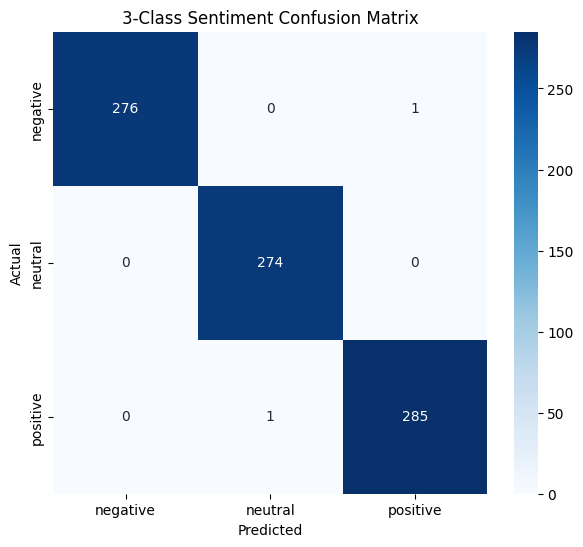

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class Sentiment Confusion Matrix")

plt.show()

In [78]:
test_comments = [
    # Positive
    "Teacher teaches very well",
    "I am very satisfied with the teaching",
    "Excellent class and very helpful teacher",
    "The teacher is supportive and helpful",
    "The classroom environment is good",

    # Negative
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "The lectures are boring",
    "Worst teaching experience",
    "The teacher is not supportive",
    "I am not satisfied with the teaching",
    "The classroom environment is not good",

    # Neutral
    "The teacher teaches the class",
    "The class is scheduled for today",
    "The teacher discussed the topic",
    "The lecture was conducted today",
    "The course has five modules",
    "The teacher gave us an assignment"
]

for comment in test_comments:

    cleaned = clean_text(comment)

    prediction = model.predict([cleaned])[0]

    probabilities = model.predict_proba([cleaned])[0]

    confidence = max(probabilities) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 75.26%

Comment: I am very satisfied with the teaching
Sentiment: positive
Confidence: 83.04%

Comment: Excellent class and very helpful teacher
Sentiment: positive
Confidence: 95.40%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 80.99%

Comment: The classroom environment is good
Sentiment: positive
Confidence: 70.66%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 87.70%

Comment: I cannot understand anything in this class
Sentiment: positive
Confidence: 46.04%

Comment: Very poor teaching
Sentiment: positive
Confidence: 77.63%

Comment: The lectures are boring
Sentiment: negative
Confidence: 75.48%

Comment: Worst teaching experience
Sentiment: positive
Confidence: 61.69%

Comment: The teacher is not supportive
Sentiment: negative
Confidence: 58.44%

Comment: I am not satisfied with the teaching
Sentiment: positive
Confidence: 76.61%

Comment: The clas

In [79]:
phrases = [
    "cannot understand",
    "poor teaching",
    "worst teaching",
    "not satisfied",
    "gave us an assignment"
]

for phrase in phrases:

    temp = df[
        df["comment"].astype(str).str.contains(
            phrase,
            case=False,
            regex=False,
            na=False
        )
    ]

    print("\n" + "=" * 70)
    print("PHRASE:", phrase)
    print("TOTAL:", len(temp))

    if len(temp) > 0:
        print("\nLabels:")
        print(temp["sentiment"].value_counts())

        print("\nExamples:")
        print(
            temp[["comment", "sentiment"]]
            .head(15)
            .to_string(index=False)
        )


PHRASE: cannot understand
TOTAL: 0

PHRASE: poor teaching
TOTAL: 0

PHRASE: worst teaching
TOTAL: 0

PHRASE: not satisfied
TOTAL: 0

PHRASE: gave us an assignment
TOTAL: 0


In [80]:
import pandas as pd

df = pd.read_csv("data/final_comments.csv")

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df.shape)
print(df["sentiment"].value_counts())

(4189, 2)
sentiment
negative    1432
positive    1386
neutral     1371
Name: count, dtype: int64


In [81]:
negative_examples = [
    "Very poor teaching",
    "Poor teaching experience",
    "The teaching quality is poor",
    "Worst teaching experience",
    "Worst teaching I have experienced",
    "The teacher is very poor at explaining",
    "I cannot understand anything in this class",
    "I cannot understand the teacher",
    "I am not satisfied with the teaching",
    "I am not satisfied with the teacher",
    "The teacher does not explain properly",
    "The teacher does not teach well",
    "The teacher is not supportive",
    "The teacher is not helpful",
    "The classroom environment is not good",
    "The lectures are boring",
    "The class is boring",
    "The teaching is not effective",
    "The explanations are not clear",
    "The teacher does not answer questions",
    "The teacher does not clear doubts",
    "The practical sessions are not useful",
    "The course is not useful",
    "I am disappointed with the teaching",
    "The teaching experience was terrible"
]

positive_examples = [
    "Teacher teaches very well",
    "Teacher explains topics clearly",
    "I am very satisfied with the teaching",
    "I am satisfied with the teacher",
    "The teacher is supportive and helpful",
    "The teacher is very helpful",
    "The teacher explains concepts clearly",
    "Excellent class and very helpful teacher",
    "Excellent teaching experience",
    "The classroom environment is good",
    "The teaching quality is good",
    "The teacher is good at explaining",
    "The lectures are interesting",
    "The class is interesting",
    "I enjoyed the class",
    "The teaching method is effective",
    "The teacher answers questions clearly",
    "The teacher clears doubts",
    "The practical sessions are useful",
    "The course is useful",
    "I am happy with the teaching",
    "The learning experience is excellent",
    "The teacher makes learning easy",
    "The teacher provides helpful examples"
]

neutral_examples = [
    "The teacher teaches the class",
    "The class is scheduled for today",
    "The teacher discussed the topic",
    "The lecture was conducted today",
    "The course has five modules",
    "The teacher gave us an assignment",
    "The teacher shared the notes",
    "The class starts at ten o'clock",
    "The teacher introduced the new topic",
    "The students attended the class",
    "The teacher completed the lecture",
    "The course contains several modules",
    "The teacher gave instructions",
    "The class was held today",
    "The students submitted the assignment"
]

In [82]:
extra_df = pd.DataFrame({
    "comment": (
        negative_examples +
        positive_examples +
        neutral_examples
    ),
    "sentiment": (
        ["negative"] * len(negative_examples) +
        ["positive"] * len(positive_examples) +
        ["neutral"] * len(neutral_examples)
    )
})

print(extra_df["sentiment"].value_counts())

sentiment
negative    25
positive    24
neutral     15
Name: count, dtype: int64


In [83]:
df = pd.concat(
    [df, extra_df],
    ignore_index=True
)

df = df.drop_duplicates(
    subset=["comment", "sentiment"]
).reset_index(drop=True)

print("Final shape:", df.shape)
print("\nDistribution:")
print(df["sentiment"].value_counts())

Final shape: (4233, 2)

Distribution:
sentiment
negative    1437
positive    1410
neutral     1386
Name: count, dtype: int64


In [84]:
import re

def clean_text(text):

    text = str(text).lower()

    # contractions
    text = text.replace("don't", "do not")
    text = text.replace("doesn't", "does not")
    text = text.replace("didn't", "did not")
    text = text.replace("can't", "cannot")
    text = text.replace("couldn't", "could not")
    text = text.replace("isn't", "is not")
    text = text.replace("wasn't", "was not")

    # URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Negation phrases
    patterns = [
        (r"\bnot\s+good\b", "not_good"),
        (r"\bnot\s+helpful\b", "not_helpful"),
        (r"\bnot\s+supportive\b", "not_supportive"),
        (r"\bnot\s+satisfied\b", "not_satisfied"),
        (r"\bnot\s+useful\b", "not_useful"),
        (r"\bnot\s+clear\b", "not_clear"),
        (r"\bdoes\s+not\s+explain\b", "does_not_explain"),
        (r"\bdoes\s+not\s+teach\b", "does_not_teach"),
        (r"\bcannot\s+understand\b", "cannot_understand"),
    ]

    for pattern, replacement in patterns:
        text = re.sub(
            pattern,
            replacement,
            text
        )

    # Keep letters, numbers, underscore
    text = re.sub(
        r"[^a-zA-Z0-9_\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_comment"] = df["comment"].apply(clean_text)

In [85]:
from sklearn.model_selection import train_test_split

X = df["clean_comment"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 3386
Test: 847


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            C=1.0,
            max_iter=3000
        )
    )
])

model.fit(X_train, y_train)

print("✅ Model trained successfully")

✅ Model trained successfully


In [87]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_pred = model.predict(X_test)

print(
    f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 99.53%

Classification Report:

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99       288
     neutral       1.00      1.00      1.00       277
    positive       1.00      0.99      0.99       282

    accuracy                           1.00       847
   macro avg       1.00      1.00      1.00       847
weighted avg       1.00      1.00      1.00       847



In [88]:
test_comments = [

    # Positive
    "The teacher is really good at explaining",
    "I am happy with the teaching quality",
    "The teacher makes difficult topics easy",
    "I really like the teaching style",
    
    # Negative
    "The teacher is unable to explain anything",
    "I learned nothing from this class",
    "The teaching experience was extremely poor",
    "This was the worst class I attended",
    "I am unhappy with the teaching",
    
    # Neutral
    "The teacher assigned homework today",
    "The lecture started at ten",
    "The teacher covered one topic today",
    "The course has six modules"
]

for comment in test_comments:

    cleaned = clean_text(comment)

    prediction = model.predict([cleaned])[0]

    probability = model.predict_proba([cleaned])[0]

    confidence = max(probability) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: The teacher is really good at explaining
Sentiment: positive
Confidence: 46.22%

Comment: I am happy with the teaching quality
Sentiment: positive
Confidence: 49.44%

Comment: The teacher makes difficult topics easy
Sentiment: negative
Confidence: 41.20%

Comment: I really like the teaching style
Sentiment: negative
Confidence: 58.63%

Comment: The teacher is unable to explain anything
Sentiment: negative
Confidence: 59.52%

Comment: I learned nothing from this class
Sentiment: negative
Confidence: 53.43%

Comment: The teaching experience was extremely poor
Sentiment: negative
Confidence: 79.52%

Comment: This was the worst class I attended
Sentiment: negative
Confidence: 53.60%

Comment: I am unhappy with the teaching
Sentiment: negative
Confidence: 52.60%

Comment: The teacher assigned homework today
Sentiment: neutral
Confidence: 69.18%

Comment: The lecture started at ten
Sentiment: neutral
Confidence: 39.24%

Comment: The teacher covered one topic today
Sentiment: neutra

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            class_weight=None
        )
    )
])

svm_model.fit(X_train, y_train)

print("✅ Linear SVM trained")

✅ Linear SVM trained


In [90]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

svm_pred = svm_model.predict(X_test)

print(
    f"Accuracy: {accuracy_score(y_test, svm_pred)*100:.2f}%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_pred
    )
)

Accuracy: 99.29%

Classification Report:
              precision    recall  f1-score   support

    negative       0.98      1.00      0.99       288
     neutral       1.00      0.99      1.00       277
    positive       1.00      0.99      0.99       282

    accuracy                           0.99       847
   macro avg       0.99      0.99      0.99       847
weighted avg       0.99      0.99      0.99       847



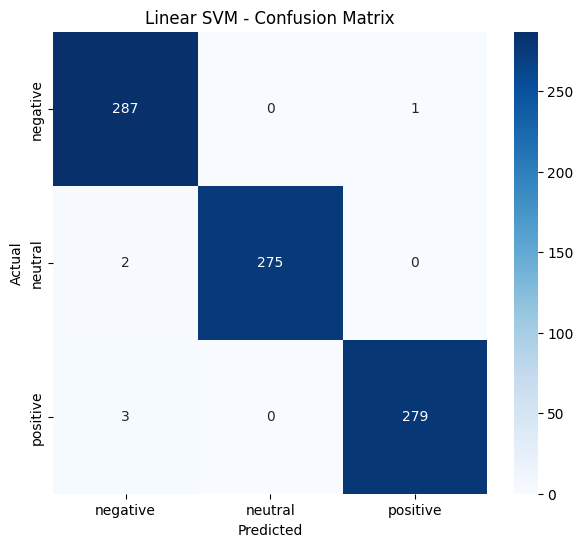

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=svm_model.classes_
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Confusion Matrix")

plt.show()

In [92]:
test_comments = [
    "The teacher is really good at explaining",
    "I am happy with the teaching quality",
    "The teacher makes difficult topics easy",
    "I really like the teaching style",

    "The teacher is unable to explain anything",
    "I learned nothing from this class",
    "The teaching experience was extremely poor",
    "This was the worst class I attended",
    "I am unhappy with the teaching",

    "The teacher assigned homework today",
    "The lecture started at ten",
    "The teacher covered one topic today",
    "The course has six modules"
]

for comment in test_comments:

    cleaned = clean_text(comment)

    prediction = svm_model.predict([cleaned])[0]

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")


Comment: The teacher is really good at explaining
Sentiment: positive

Comment: I am happy with the teaching quality
Sentiment: positive

Comment: The teacher makes difficult topics easy
Sentiment: positive

Comment: I really like the teaching style
Sentiment: negative

Comment: The teacher is unable to explain anything
Sentiment: negative

Comment: I learned nothing from this class
Sentiment: negative

Comment: The teaching experience was extremely poor
Sentiment: negative

Comment: This was the worst class I attended
Sentiment: negative

Comment: I am unhappy with the teaching
Sentiment: negative

Comment: The teacher assigned homework today
Sentiment: neutral

Comment: The lecture started at ten
Sentiment: neutral

Comment: The teacher covered one topic today
Sentiment: neutral

Comment: The course has six modules
Sentiment: neutral


In [93]:
from sklearn.metrics import accuracy_score, classification_report

svm_pred = svm_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, svm_pred)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Accuracy: 99.29%

Classification Report:
              precision    recall  f1-score   support

    negative       0.98      1.00      0.99       288
     neutral       1.00      0.99      1.00       277
    positive       1.00      0.99      0.99       282

    accuracy                           0.99       847
   macro avg       0.99      0.99      0.99       847
weighted avg       0.99      0.99      0.99       847



In [94]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

final_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=1,
            max_df=0.98,
            sublinear_tf=True,
            max_features=30000
        )
    ),

    (
        "classifier",
        CalibratedClassifierCV(
            LinearSVC(C=1.0),
            cv=5
        )
    )
])

final_model.fit(X_train, y_train)

print("✅ Final model trained")
print("Classes:", final_model.classes_)

✅ Final model trained
Classes: ['negative' 'neutral' 'positive']


In [95]:
test_comments = [
    "Teacher teaches very well",
    "I am very satisfied with the teaching",
    "The teacher does not explain properly",
    "I cannot understand anything in this class",
    "Very poor teaching",
    "The lectures are boring",
    "The teacher is supportive and helpful",
    "The classroom environment is good",
    "The classroom environment is not good",
    "The teacher gave us an assignment"
]

for comment in test_comments:

    cleaned = clean_text(comment)

    prediction = final_model.predict([cleaned])[0]

    probabilities = final_model.predict_proba([cleaned])[0]

    confidence = max(probabilities) * 100

    print(f"\nComment: {comment}")
    print(f"Sentiment: {prediction}")
    print(f"Confidence: {confidence:.2f}%")


Comment: Teacher teaches very well
Sentiment: positive
Confidence: 94.34%

Comment: I am very satisfied with the teaching
Sentiment: positive
Confidence: 95.01%

Comment: The teacher does not explain properly
Sentiment: negative
Confidence: 99.16%

Comment: I cannot understand anything in this class
Sentiment: negative
Confidence: 89.38%

Comment: Very poor teaching
Sentiment: negative
Confidence: 94.45%

Comment: The lectures are boring
Sentiment: negative
Confidence: 98.23%

Comment: The teacher is supportive and helpful
Sentiment: positive
Confidence: 91.43%

Comment: The classroom environment is good
Sentiment: positive
Confidence: 95.45%

Comment: The classroom environment is not good
Sentiment: negative
Confidence: 99.57%

Comment: The teacher gave us an assignment
Sentiment: neutral
Confidence: 91.54%


In [96]:
import joblib

joblib.dump(
    final_model,
    "sentiment_model.pkl"
)

print("✅ Final model saved successfully")

✅ Final model saved successfully
